# Воспроизведение абляции числа шагов распространения K в SGC

**Цель:** проверить главную гипотезу статьи "Simplifying Graph Convolutional Networks" – качество SGC растёт с увеличением рецептивного поля до определённого предела, после чего может выйти на плато или упасть.

Эксперимент обучает SGC для K = 1,2,3,4, сравнивает с линейным бейзлайном (K=0) и двухслойным GCN на датасете Cora. Результат – график точности и итоговая таблица.

## 0. Подготовка окружения
Если вы запускаете ноутбук в Google Colab, раскомментируйте и выполните ячейку ниже для установки необходимых библиотек.

In [48]:
# !pip install torch torch-geometric

## 1. Импорты и фиксация случайных чисел

In [49]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
import torch.nn as nn
from torch_geometric.nn import GCNConv
from torch_geometric.utils import add_self_loops, to_scipy_sparse_matrix

import numpy as np
import scipy.sparse as sp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time
import warnings

warnings.filterwarnings('ignore')

# Воспроизводимость
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cpu


## 2. Загрузка датасета Cora

In [50]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]  # Пока оставим на CPU, для GCN перенесём позже

edge_index = data.edge_index.cpu()
x = data.x.cpu().numpy()  # numpy для SGC
y = data.y.cpu().numpy()
train_mask = data.train_mask.cpu().numpy()
test_mask = data.test_mask.cpu().numpy()

num_nodes = x.shape[0]
num_features = x.shape[1]
num_classes = dataset.num_classes

print(f'Вершин: {num_nodes}, признаков: {num_features}, классов: {num_classes}')

Вершин: 2708, признаков: 1433, классов: 7


## 3. Предобработка признаков для SGC

Вычисляем симметрично нормализованную матрицу смежности с петлями $\tilde{S} = \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2}$, затем применяем $K$ раз: $\tilde{S}^K X$.

In [51]:
def compute_sgc_features(k, edge_index, x, num_nodes):
    """
    Возвращает предобработанные признаки S^K X.
    k : число шагов распространения
    """
    # Добавляем self-loops (A_ij = A_ij + I_ij)
    edge_index_loop, _ = add_self_loops(edge_index, num_nodes=num_nodes)
    # Разреженная матрица смежности (scipy)
    adj = to_scipy_sparse_matrix(edge_index_loop, num_nodes=num_nodes)

    # Симметричная нормализация
    degrees = np.array(adj.sum(axis=1)).flatten()
    deg_inv_sqrt = np.power(degrees, -0.5)
    deg_inv_sqrt[~np.isfinite(deg_inv_sqrt)] = 0.0
    D_inv_sqrt = sp.diags(deg_inv_sqrt)
    S = D_inv_sqrt @ adj @ D_inv_sqrt

    # Применяем S к признакам k раз: X <- S @ X
    features = x.copy()
    for _ in range(k):
        features = S @ features
    return features

## 4. Обучение логистической регрессии – SGC и линейный бейзлайн (K=0)

In [52]:
K_list = [0, 1, 2, 3, 4]  # 0 соответствует исходным признакам (линейный baseline)
sgc_acc = {}
sgc_times = {}

for K in K_list:
    t0 = time.time()
    if K == 0:
        features_transformed = x
    else:
        features_transformed = compute_sgc_features(K, edge_index, x, num_nodes)

    # Логистическая регрессия (L2-регуляризация по умолчанию C=1.0)
    clf = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=seed)
    clf.fit(features_transformed[train_mask], y[train_mask])
    pred = clf.predict(features_transformed[test_mask])
    acc = accuracy_score(y[test_mask], pred) * 100
    sgc_acc[K] = acc
    sgc_times[K] = time.time() - t0
    print(f'SGC (K={K}): Test Accuracy = {acc:.2f}%, время обучения = {sgc_times[K]:.4f} сек')

SGC (K=0): Test Accuracy = 57.60%, время обучения = 0.0596 сек
SGC (K=1): Test Accuracy = 78.50%, время обучения = 0.0674 сек
SGC (K=2): Test Accuracy = 82.50%, время обучения = 0.0920 сек
SGC (K=3): Test Accuracy = 82.60%, время обучения = 0.1397 сек
SGC (K=4): Test Accuracy = 82.30%, время обучения = 0.1065 сек


## 5. Обучение двухслойного GCN (baseline из статьи)

In [53]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.dropout = nn.Dropout(p=dropout)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

# Переносим данные на нужное устройство
data = data.to(device)
model = GCN(dataset.num_features, 16, dataset.num_classes, dropout=0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

model.train()
for epoch in range(1, 401):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        model.eval()
        with torch.no_grad():
            pred = out.argmax(dim=1)
            train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item() * 100
            test_acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item() * 100
        model.train()
        print(f'Epoch {epoch:3d}: Train Acc {train_acc:.2f}%, Test Acc {test_acc:.2f}%')

# Финальная оценка
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    gcn_test_acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item() * 100
print(f'\nGCN Final Test Accuracy: {gcn_test_acc:.2f}%')

# Количество параметров
gcn_params = sum(p.numel() for p in model.parameters())
sgc_params = num_features * num_classes + num_classes  # веса + bias логистической регрессии

Epoch  50: Train Acc 99.29%, Test Acc 76.10%
Epoch 100: Train Acc 99.29%, Test Acc 75.70%
Epoch 150: Train Acc 100.00%, Test Acc 72.70%
Epoch 200: Train Acc 99.29%, Test Acc 76.80%
Epoch 250: Train Acc 100.00%, Test Acc 78.00%
Epoch 300: Train Acc 100.00%, Test Acc 77.30%
Epoch 350: Train Acc 100.00%, Test Acc 78.50%
Epoch 400: Train Acc 100.00%, Test Acc 76.80%

GCN Final Test Accuracy: 80.90%


## 6. Результаты: таблица и график


----------------------------------------
Модель               Test Accuracy (%)  Параметры
----------------------------------------
Linear (K=0)         57.60              10038
SGC (K=1)            78.50              10038
SGC (K=2)            82.50              10038
SGC (K=3)            82.60              10038
SGC (K=4)            82.30              10038
GCN                  80.90              23063


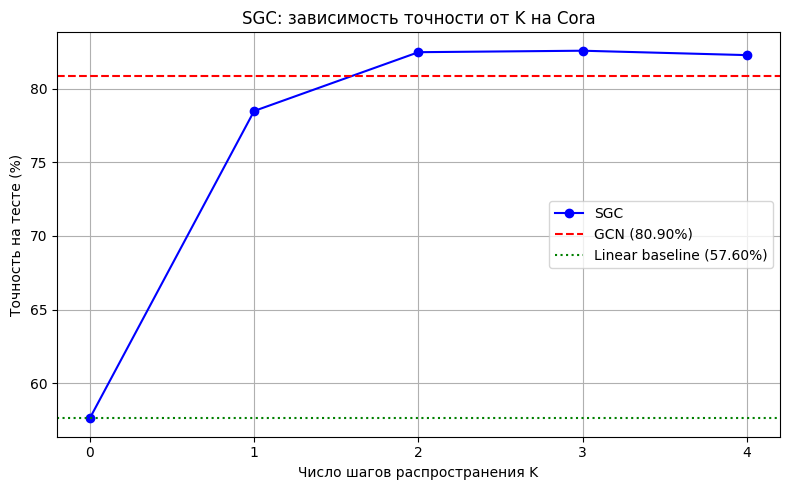


График сохранён в sgc_ablation_K.pdf


In [54]:
print('\n' + '-' * 40)
print(f"{'Модель':<20} {'Test Accuracy (%)':<18} {'Параметры'}")
print('-' * 40)
print(f"{'Linear (K=0)':<20} {sgc_acc[0]:<18.2f} {sgc_params}")
for K in [1, 2, 3, 4]:
    print(f"{'SGC (K=' + str(K) + ')':<20} {sgc_acc[K]:<18.2f} {sgc_params}")
print(f"{'GCN':<20} {gcn_test_acc:<18.2f} {gcn_params}")

# Построение графика
plt.figure(figsize=(8, 5))
plt.plot(K_list, [sgc_acc[k] for k in K_list], marker='o', label='SGC', color='b')
plt.axhline(y=gcn_test_acc, color='r', linestyle='--', label=f'GCN ({gcn_test_acc:.2f}%)')
plt.axhline(y=sgc_acc[0], color='g', linestyle=':', label=f'Linear baseline ({sgc_acc[0]:.2f}%)')
plt.xlabel('Число шагов распространения K')
plt.ylabel('Точность на тесте (%)')
plt.title('SGC: зависимость точности от K на Cora')
plt.legend()
plt.grid(True)
plt.xticks(K_list)
plt.tight_layout()
plt.savefig('sgc_ablation_K.pdf')
plt.show()

print('\nГрафик сохранён в sgc_ablation_K.pdf')